<a href="https://colab.research.google.com/github/ruforavishnu/Project_Simulations/blob/main/12th_Standard_Maths_Chapter6_Application_of_Derivatives.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Application of Derivatives

### Problem
Roney's father was making a storage box from a rectangular cardboard sheet of size **50 cm × 32 cm**.

When he decided to cut equal squares from the four corners and fold the sides up to form an open box, he realized he didn't have enough cardboard left to do so. So he sends Roney to the hardware shop to buy a new sheet.

How much cardboard should he purchase from the shop so that he gets maximum storage capacity out of the box?
What should be the side length of the squares to be cut out in order to achieve that?

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [18]:
x = sp.symbols('x', real=True, positive=True)


In [19]:
L = 50
W = 32

In [20]:
V = x * (L - 2*x) * (W - 2*x)

V

x*(32 - 2*x)*(50 - 2*x)

**now lets differentiate**

In [21]:
dV = sp.diff(V , x)
dV

-2*x*(32 - 2*x) - 2*x*(50 - 2*x) + (32 - 2*x)*(50 - 2*x)

In [22]:
critical_points = sp.solve(sp.Eq(dV,0)  , x)
critical_points

[41/3 - sqrt(481)/3, sqrt(481)/3 + 41/3]

In [23]:
valid = [cp.evalf() for cp in critical_points if 0 < cp.evalf() < min(L/2, W/2)]
valid

[6.35609593351290]

**second derivative**

In [27]:
d2V = sp.diff(V, x, 2)

for cp in valid:
  if d2V.subs(x, cp) < 0:
    opt_x = float(cp)
    opt_V = float(V.subs(x, cp))






In [29]:
length = L - 2*opt_x
width = W - 2*opt_x
height = opt_x

print(f'Optimal square cut: {opt_x:.2f} cm')
print(f'Maximum volume: {opt_V:.2f} cm³')
print(f'Resulting box dimensions : {length:.2f} x {width:.2f} x {height:.2f} cm')
print(f'Roney should buy atleast {int(L) + 2} x {int(W) +2} cm cardboard (≈ {L+2} x {W+2} ) to reproduce this maximum box.')


Optimal square cut: 6.36 cm
Maximum volume: 4571.30 cm³
Resulting box dimensions : 37.29 x 19.29 x 6.36 cm
Roney should buy atleast 52 x 34 cm cardboard (≈ 52 x 34 ) to reproduce this maximum box.


**fine. now lets plot it**

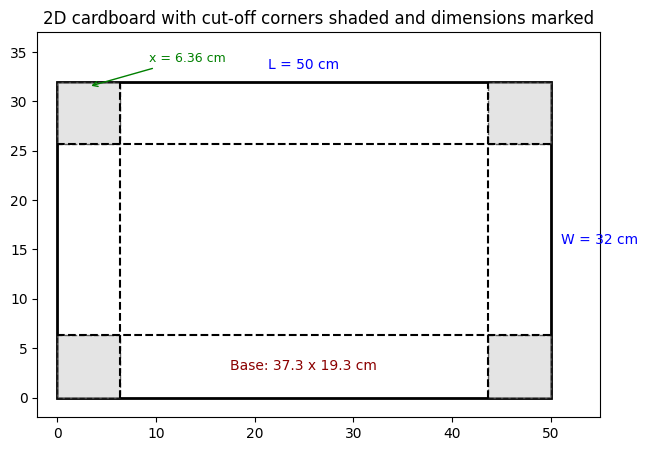

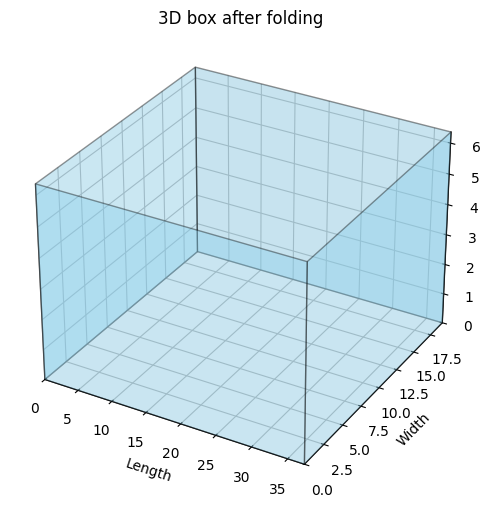

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

rect = plt.Rectangle( (0,0),  L, W,  fill=None,  edgecolor='black', linewidth=2)
ax.add_patch(rect)

corners = [
            (0,0),
            (L - opt_x, 0),
            (0, W - opt_x),
            ( L - opt_x, W - opt_x)


]


for (cx, cy) in corners:
  square = plt.Rectangle( (cx, cy),  opt_x,  opt_x,  facecolor='lightgrey', edgecolor='black', linestyle='--', alpha=0.6)
  ax.add_patch(square)



ax.plot( [ opt_x, opt_x], [0,W], linestyle='--', color='black')
ax.plot( [L - opt_x, L - opt_x], [0,W], linestyle='--', color='black')
ax.plot( [0, L], [opt_x , opt_x], linestyle='--', color='black')
ax.plot( [0,L], [W-opt_x, W-opt_x], linestyle='--', color='black')

ax.text(L/2, W+1, f"L = {L} cm", ha='center', va='bottom', fontsize=10, color='blue')
ax.text(L+1, W/2, f"W = {W} cm", ha='left', va='center', fontsize=10, color='blue')


inner_L = L - 2*opt_x
inner_W = W - 2*opt_x
ax.text(L/2, opt_x/2, f'Base: {inner_L:.1f} x {inner_W:.1f} cm', ha='center', va='center', fontsize=10,color='darkred')

ax.annotate(f"x = {opt_x:.2f} cm",
            xy=(opt_x/2, W-0.5), xytext=(opt_x+3, W+2),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=9, color='green')



ax.set_xlim(-2, L+5)
ax.set_ylim(-2, W+5)

ax.set_aspect('equal')
ax.set_title('2D cardboard with cut-off corners shaded and dimensions marked')
plt.show()


### the 3d plotting section
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

bottom = [ [(0,0,0), (length, 0,0) , (length, 0, height),  (0,0,height)  ],
          [(0,width,0), (length, width,0) , (length, width, height),  (0,width,height)  ],
           [(0,0,0), (0,width, 0) , (0,width, height),  (0,0,height)  ],
           [(length,0,0), (length, width,0) , (length, width, height),  (length,0,height)  ]

]

ax.add_collection3d( Poly3DCollection(sides, facecolors='skyblue',alpha=0.4, edgecolor='black'))

ax.set_xlim(0, length)
ax.set_ylim(0, width)
ax.set_zlim(0, height)
ax.set_xlabel('Length')
ax.set_ylabel('Width')
ax.set_zlabel('Height')
ax.set_title('3D box after folding')
ax.grid(True)

plt.show()










### Problem

Rincy wants to bake cookies and store them in a cylindrical glass jar.  
The jar should hold **2.0 L** ( $2000 \,\text{cm}^3$
) of cookies. Glass jars are expensive. So help her calculate:



1. What radius and height of the jar will use the least glass (i.e., minimize the total surface area) while keeping the volume fixed at 2.0 L?”



In [40]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection




In [42]:
V_liters = 2.0
V = V_liters * 1000.0

pi = sp.pi



In [43]:
r = sp.symbols('r', positive=True)

S = (2 * pi * r**2) + (2*V/r)

**differentiate it**

In [44]:
dS = sp.diff(S, r)

r_crit =  sp.solve( sp.Eq(dS,0)  , r)


r_opt = float([ val for val in r_crit if val.is_real and val >0][0])
h_opt = float( (V) / (np.pi*r_opt**2)  )



**second derivative**

In [49]:
d2S = sp.diff(S, r, 2)
d2S_val = float(d2S.subs(r, r_opt))

S_opt = float(S.subs(r, r_opt))

print(f'=== Optimization results for our Cookie Jar ===')
print(f'Desired Volume: {V_liters:.2f} L = {V:.0f} cm³')

print(f'\nSo required optimal radius r = {r_opt:.4f} cm')
print(f'So required optimal height h = {h_opt:.4f} cm')
print(f'Optimized Surface area of the glass so we minimize expenses is S = {S_opt:.2f} cm²')




=== Optimization results for our Cookie Jar ===
Desired Volume: 2.00 L = 2000 cm³

So required optimal radius r = 6.8278 cm
So required optimal height h = 13.6557 cm
Optimized Surface area of the glass so we minimize expenses is S = 878.76 cm²


**fine, now lets plot it**

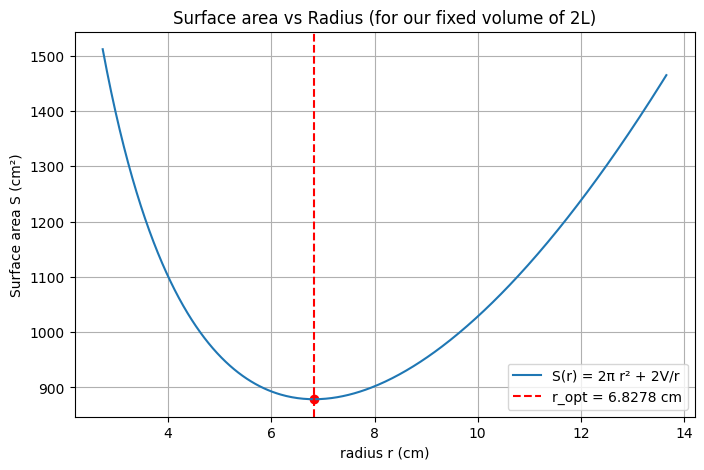

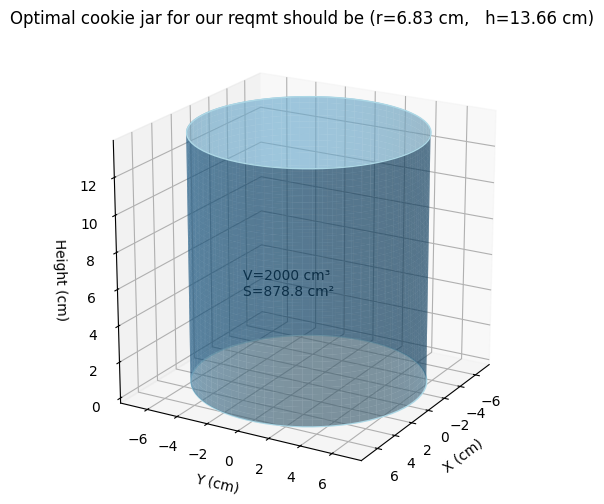

In [53]:
r_vals = np.linspace(max(0.1, r_opt*0.4), r_opt*2.0, 400)
S_vals = 2*np.pi*r_vals**2 + 2*V/r_vals

plt.figure(figsize=(8,5))
plt.plot(r_vals, S_vals, label='S(r) = 2π r² + 2V/r')
plt.axvline(r_opt, color='red', linestyle='--', label=f'r_opt = {r_opt:.4f} cm')
plt.scatter([r_opt], [S_opt], color='red')
plt.title('Surface area vs Radius (for our fixed volume of 2L)')
plt.xlabel('radius r (cm)')
plt.ylabel('Surface area S (cm²)')
plt.grid(True)
plt.legend()
plt.show()



## 3d plotting
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')


rnum = r_opt
hnum = h_opt
theta = np.linspace(0, 2*np.pi, 80)
z = np.linspace(0, hnum, 40)

theta_grid, z_grid = np.meshgrid(theta, z)
x_grid = rnum * np.cos(theta_grid)
y_grid = rnum * np.sin(theta_grid)

ax.plot_surface(x_grid, y_grid, z_grid, rstride=1, cstride=1, alpha=0.45, linewidth=0, shade=True)

top_x = rnum * np.cos(theta)
top_y = rnum * np.sin(theta)
ax.add_collection3d(Poly3DCollection([list(zip(top_x, top_y, np.full_like(top_x, 0)   )) ],
                                     color='lightblue', alpha=0.35))

ax.add_collection3d(Poly3DCollection([list(zip(top_x, top_y, np.full_like(top_x, hnum)  ))],
                                     color='lightblue', alpha=0.34
                                     ))

ax.set_box_aspect([rnum*2, rnum*2, hnum])
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_zlabel('Height (cm)')
ax.set_title(f'Optimal cookie jar for our reqmt should be (r={rnum:.2f} cm,   h={hnum:.2f} cm)')
ax.text(1.05* rnum, 0, hnum*0.5, f'V={V:.0f} cm³\nS={S_opt:.1f} cm²', fontsize=10)
ax.view_init(elev=20, azim=30)
plt.show()



**fine, so thats also sorted**